<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/13_pytorch_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Notebook 13 — 🔥 PyTorch Basics: Your First Neural Network

> **Advanced & Self-Learning Track — Notebook 13 of 14** · **Estimated time:** 45–55 min · **Difficulty:** Intermediate
>
> This track is the self-paced deep-dive of the course; the 90-minute live **Introduction Session** lives in `01_introduction/`.

In notebooks 11 and 12 you learned the machine-learning rhythm: **split → prepare → fit → predict → evaluate**, and you let scikit-learn do the fitting for you behind a one-line `model.fit(X_train, y_train)`.

This notebook keeps exactly that rhythm but changes the toolkit. **PyTorch** is what researchers and engineers use to build neural networks, and the price of its flexibility is that *you* write the training loop by hand. That sounds intimidating; it is about eight lines of code. Once you have written it, the fog around "deep learning" clears considerably — including around the very large models currently in the news, which are trained by the same loop.

> **The goal here is familiarity, not mastery.** By the end you will know what a tensor is, what a gradient is, how a neural network is assembled, and how the training loop works. Becoming *good* at deep learning takes much longer — this notebook makes sure you are not starting from zero.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Explain what PyTorch is, and decide **when to reach for it instead of scikit-learn** — and when not to.
2. Create and inspect **tensors**, and move data between NumPy and PyTorch.
3. Do elementwise arithmetic, **broadcasting**, matrix multiplication, reductions with `dim=`, reshaping and slicing on tensors.
4. Describe what **autograd** does, and verify a gradient PyTorch computed against one you worked out by hand.
5. Explain what a **neural network** is — stacked linear layers plus a non-linearity — and why the non-linearity is not optional.
6. Build the same small model **two ways**: with `nn.Sequential` and as a `class Net(nn.Module)`.
7. Write the canonical **training loop** (forward → loss → `zero_grad` → `backward` → `step`) and say why `zero_grad()` is there.
8. Run a **complete end-to-end workflow** on a real tabular dataset and compare the result honestly against a scikit-learn baseline.
9. Name the next things to learn: `Dataset`/`DataLoader`, GPUs, and the architectures built on top of this loop.

## ✅ Prerequisites

Notebooks 1–12 of this track. Three of them matter most here:

- **Notebook 6 — NumPy Fundamentals**: arrays, `shape`, `dtype`, broadcasting, `axis=`. A tensor is a NumPy array with two extra powers, so this is the closest relative.
- **Notebook 8 — Data Cleaning and Preprocessing**: feature scaling with `StandardScaler`. Neural networks genuinely need it.
- **Notebooks 11 & 12 — ML Basics and the Scikit-Learn Workflow**: train/test split, features vs target, overfitting, evaluation metrics. We reuse all of it; only the fitting step changes.

## ⚡ Running this notebook

**Google Colab has PyTorch preinstalled** — there is nothing to install, just `import torch`. Everything in this notebook runs **on the CPU in a few seconds**: the datasets are tiny and the networks have a few hundred parameters. **No GPU is needed**, and you do not need to change the Colab runtime type.

## 1. What PyTorch is, and why people use it

Strip away the hype and PyTorch is three things bolted together:

1. **A numerical array library** — like NumPy, but its arrays are called **tensors** and they can live on a GPU.
2. **Automatic differentiation ("autograd")** — it *records* the calculations you perform and can then compute the derivative of any result with respect to any input. This is the machinery that lets a model learn from its mistakes.
3. **A neural-network toolbox** — ready-made layers (`torch.nn`), loss functions, and optimisers (`torch.optim`), so you assemble models from parts instead of writing calculus.

**The ecosystem in one paragraph.** PyTorch (Meta, now the PyTorch Foundation) and TensorFlow/Keras (Google) are the two dominant deep-learning frameworks; PyTorch has become the default in research and increasingly in industry because it is plain, debuggable Python. On top of it sits a large ecosystem — Hugging Face `transformers` for language and vision models, `torchvision`/`torchaudio` for data and pretrained models, PyTorch Lightning for training infrastructure. When you read that a model was "fine-tuned" or "trained from scratch", it was very likely done with the pieces you are about to see.

### When PyTorch — and when scikit-learn?

Deep learning is not automatically better. It is a *different trade-off*, and being honest about that is part of being competent.

| Reach for **PyTorch** when… | Stay with **scikit-learn** when… |
|---|---|
| Your data is images, audio, text, or sequences | Your data is a table of numbers and categories |
| You need a **custom** model architecture or loss function | A standard model does the job |
| You have a **lot** of data (tens of thousands of rows and up) | You have hundreds or a few thousand rows |
| You want to fine-tune a **pretrained** model | You need a strong **baseline** in five lines of code |
| A **GPU** is available and the model is big enough to need one | Training must be fast, cheap and reproducible on a laptop |
| You want fine-grained control over the training process | You want `fit` / `predict` / `score` and cross-validation for free |

**The practical rule:** on small or medium **tabular** data, gradient-boosted trees and even logistic regression usually match or beat a neural network — with less tuning, less code and more interpretability. Section 9 of this notebook demonstrates exactly that, on purpose. PyTorch earns its keep when the *structure* of the data (pixels, tokens, waveforms) is something a neural network can exploit, or when you need to build something that does not exist as an off-the-shelf estimator.

## 2. Setup

One import cell for the whole notebook. We also fix the random seeds so that every number printed below is reproducible, and set up the course plot palette.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn          # layers, activations, loss functions
import torch.optim as optim    # optimisers (SGD, Adam, ...)

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)

# Reproducibility: same seed -> same numbers every run
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version :", torch.__version__)
print("NumPy version   :", np.__version__)

PyTorch version : 2.8.0
NumPy version   : 2.0.2


### The `device` one-liner

Every PyTorch script you will ever read starts with some version of this line:

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
```

`"cuda"` means an NVIDIA GPU. The line says: *use a GPU if one is available, otherwise fall back to the CPU.* You then move your model and your data to that device with `.to(device)`, and the same code runs unchanged on a laptop and on a compute cluster. This is standard practice — write it once, never think about it again.

Everything in this notebook is small enough that the CPU is *faster* than a GPU (moving data to a GPU costs time too), so you will see `cpu` below unless you deliberately picked a GPU runtime. That is fine and expected.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# On Apple Silicon there is a third option, "mps". The full idiom:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Best available device:", device)

# For this notebook we deliberately stay on the CPU: the models are tiny,
# and CPU keeps the results identical for everyone.
device = "cpu"

Using device: cpu
Best available device: mps


## 3. Tensors — NumPy arrays with two superpowers

> **A tensor is a NumPy array that can also carry gradients and move to a GPU.**

That is the whole idea. If you were comfortable with `np.array` in notebook 6, you are already 90 % comfortable with `torch.Tensor`: same rectangular block of numbers, same `shape`, same `dtype`, same indexing. The names of a few methods differ (`dim=` instead of `axis=`, `.view()` alongside `.reshape()`), and two capabilities are new:

- **`requires_grad`** — the tensor remembers how it was computed, so PyTorch can differentiate through it (section 5).
- **`.to(device)`** — the tensor's numbers can be moved to GPU memory.

The vocabulary "tensor" just means *n-dimensional array*: a scalar is a 0-D tensor, a vector 1-D, a matrix 2-D, a batch of colour images 4-D `(batch, channels, height, width)`.

### 3.1 Creating tensors

In [3]:
# From a Python list of lists — exactly like np.array
t = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
print(t)
print("shape:", t.shape)      # torch.Size([2, 3]) — rows, columns
print("dtype:", t.dtype)      # torch.float32
print("ndim :", t.dim())      # number of dimensions

tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
ndim : 2


In [4]:
# The standard constructors — the NumPy names you already know
print("zeros(2, 3):\n", torch.zeros(2, 3))
print("ones(3)     :", torch.ones(3))
print("arange      :", torch.arange(0, 10, 2))       # like np.arange
print("linspace    :", torch.linspace(0, 1, 5))      # 5 points from 0 to 1

# Random numbers: seed FIRST, then draw, and the numbers are reproducible
torch.manual_seed(0)
r = torch.randn(2, 3)          # standard normal, mean 0, std 1
print("randn(2, 3):\n", r)

zeros(2, 3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones(3)     : tensor([1., 1., 1.])
arange      : tensor([0, 2, 4, 6, 8])
linspace    : tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
randn(2, 3):
 tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986]])


> 💡 **`dtype` trap, PyTorch edition.** NumPy defaults to `float64`; PyTorch defaults to **`float32`** — half the memory, plenty of precision for neural networks, and what GPUs are fast at. Two consequences you will meet in practice:
>
> - `torch.tensor([1, 2, 3])` is an **integer** tensor (`int64`) and cannot carry gradients. Write `torch.tensor([1.0, 2.0, 3.0])` or pass `dtype=torch.float32`.
> - Data converted from NumPy arrives as `float64` and often has to be cast to `float32` (you will do exactly that in section 9).

### 3.2 The NumPy bridge

PyTorch and NumPy speak the same memory format, so converting is free — the two objects can even *share* the same numbers.

In [5]:
a = np.array([[1.0, 2.0],
              [3.0, 4.0]])

t_from_np = torch.from_numpy(a)          # NumPy  -> tensor  (shares memory!)
back_to_np = t_from_np.numpy()           # tensor -> NumPy   (shares memory!)

print("numpy dtype :", a.dtype)          # float64
print("tensor dtype:", t_from_np.dtype)  # torch.float64 — the dtype carried over
print("round trip  :", type(back_to_np).__name__)

# "Shares memory" is not a figure of speech — change the NumPy array...
a[0, 0] = 99.0
print("\ntensor after editing the NumPy array:\n", t_from_np)

# If you want an independent copy, ask for one:
t_copy = torch.tensor(a)                 # copies the data (a[0, 0] is 99 right now)

a[0, 0] = 1.0                            # change the NumPy array once more
print("\nthe SHARED tensor followed the change:\n", t_from_np)
print("the COPY kept the old value:\n", t_copy)

numpy dtype : float64
tensor dtype: torch.float64
round trip  : ndarray

tensor after editing the NumPy array:
 tensor([[99.,  2.],
        [ 3.,  4.]], dtype=torch.float64)

the SHARED tensor followed the change:
 tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
the COPY kept the old value:
 tensor([[99.,  2.],
        [ 3.,  4.]], dtype=torch.float64)


**Why this matters.** Every dataset you have used in this course — pandas DataFrames, scikit-learn's `load_*` arrays — is NumPy underneath. `torch.tensor(array, dtype=torch.float32)` is therefore the standard on-ramp from "data science data" to "PyTorch data", and it is the line that starts section 9.

## 4. Tensor operations

Nothing in this section is conceptually new if you did notebook 6 — it is the same NumPy semantics with PyTorch spelling. **Print the shape at every step**; shape mismatches are the single most common bug in deep-learning code.

### 4.1 Elementwise arithmetic and broadcasting

In [6]:
A = torch.arange(6.0).reshape(2, 3)     # note the 6.0 -> float tensor
print("A =\n", A, "\nshape:", A.shape)

print("\nA * 2 (scalar broadcast):\n", A * 2)
print("\nA + A (same shapes, elementwise):\n", A + A)
print("\ntorch.exp(A) (elementwise function):\n", torch.exp(A).round(decimals=2))

A =
 tensor([[0., 1., 2.],
        [3., 4., 5.]]) 
shape: torch.Size([2, 3])

A * 2 (scalar broadcast):
 tensor([[ 0.,  2.,  4.],
        [ 6.,  8., 10.]])

A + A (same shapes, elementwise):
 tensor([[ 0.,  2.,  4.],
        [ 6.,  8., 10.]])

torch.exp(A) (elementwise function):
 tensor([[  1.0000,   2.7200,   7.3900],
        [ 20.0900,  54.6000, 148.4100]])


In [7]:
# Broadcasting — identical rules to NumPy (notebook 6):
# compare shapes from the right; a dimension of size 1 (or missing) is stretched.
row = torch.tensor([100.0, 200.0, 300.0])   # shape (3,)   -> one value per COLUMN
col = torch.tensor([[10.0], [20.0]])        # shape (2, 1) -> one value per ROW

print("A shape        :", tuple(A.shape))
print("row shape      :", tuple(row.shape), "-> broadcast over rows")
print(A + row)
print("\ncol shape      :", tuple(col.shape), "-> broadcast over columns")
print(A + col)
print("\nresult shape   :", tuple((A + col).shape))

A shape        : (2, 3)
row shape      : (3,) -> broadcast over rows
tensor([[100., 201., 302.],
        [103., 204., 305.]])

col shape      : (2, 1) -> broadcast over columns
tensor([[10., 11., 12.],
        [23., 24., 25.]])

result shape   : (2, 3)


### 4.2 Matrix multiplication

`*` is **elementwise**; `@` is **matrix multiplication**. Confusing the two is a rite of passage. The shape rule: `(n, k) @ (k, m) -> (n, m)` — the inner dimensions must match, and they *cancel*.

A neural network layer is literally one `@` plus one addition, so this operation is the workhorse of everything that follows.

In [8]:
B = torch.ones(3, 2)

print("A shape      :", tuple(A.shape))
print("B shape      :", tuple(B.shape))
print("A @ B shape  :", tuple((A @ B).shape), "   <- (2,3) @ (3,2) = (2,2)")
print("A @ B =\n", A @ B)

# .T transposes, exactly as in NumPy
print("\nA.T shape    :", tuple(A.T.shape))
print("A @ A.T shape:", tuple((A @ A.T).shape))

A shape      : (2, 3)
B shape      : (3, 2)
A @ B shape  : (2, 2)    <- (2,3) @ (3,2) = (2,2)
A @ B =
 tensor([[ 3.,  3.],
        [12., 12.]])

A.T shape    : (3, 2)
A @ A.T shape: (2, 2)


### 4.3 Reductions: `dim=` is PyTorch's `axis=`

The one piece of vocabulary you must re-learn from NumPy. The meaning is unchanged: **the dimension you name is the one that disappears.**

- `dim=0` collapses the rows → one value **per column**
- `dim=1` collapses the columns → one value **per row**

In [9]:
print("A =\n", A)
print("\nA.sum()        :", A.sum(), "  <- everything, a 0-D tensor")
print("A.sum(dim=0)   :", A.sum(dim=0), "  <- per column (2 rows collapsed)")
print("A.sum(dim=1)   :", A.sum(dim=1), "  <- per row (3 columns collapsed)")
print("A.mean(dim=1)  :", A.mean(dim=1))
print("A.max()        :", A.max())

# A 0-D tensor is still a tensor. .item() extracts a plain Python number —
# you will use it constantly to log losses.
print("\nA.sum().item() :", A.sum().item(), type(A.sum().item()).__name__)

A =
 tensor([[0., 1., 2.],
        [3., 4., 5.]])

A.sum()        : tensor(15.)   <- everything, a 0-D tensor
A.sum(dim=0)   : tensor([3., 5., 7.])   <- per column (2 rows collapsed)
A.sum(dim=1)   : tensor([ 3., 12.])   <- per row (3 columns collapsed)
A.mean(dim=1)  : tensor([1., 4.])
A.max()        : tensor(5.)

A.sum().item() : 15.0 float


### 4.4 Reshaping, indexing, slicing

In [10]:
print("A                 :", tuple(A.shape))
print("A.reshape(3, 2)   :", tuple(A.reshape(3, 2).shape))
print("A.view(3, 2)      :", tuple(A.view(3, 2).shape), "  <- same result, needs contiguous memory")
print("A.reshape(-1)     :", tuple(A.reshape(-1).shape), "     <- -1 means 'work it out'")
print("A.reshape(-1, 1)  :", tuple(A.reshape(-1, 1).shape), "  <- column vector; very common")

print("\nIndexing / slicing — the NumPy rules, unchanged:")
print("A[1]      (row 1)      :", A[1])
print("A[:, 0]   (column 0)   :", A[:, 0])
print("A[0, 2]   (one element):", A[0, 2].item())
print("A[:, 1:]  (cols 1..)   :\n", A[:, 1:])
print("A[A > 2]  (boolean mask):", A[A > 2])

A                 : (2, 3)
A.reshape(3, 2)   : (3, 2)
A.view(3, 2)      : (3, 2)   <- same result, needs contiguous memory
A.reshape(-1)     : (6,)      <- -1 means 'work it out'
A.reshape(-1, 1)  : (6, 1)   <- column vector; very common

Indexing / slicing — the NumPy rules, unchanged:
A[1]      (row 1)      : tensor([3., 4., 5.])
A[:, 0]   (column 0)   : tensor([0., 3.])
A[0, 2]   (one element): 2.0
A[:, 1:]  (cols 1..)   :
 tensor([[1., 2.],
        [4., 5.]])
A[A > 2]  (boolean mask): tensor([3., 4., 5.])


> 💡 **`view` vs `reshape`.** `view` returns a new *view* on the same memory and fails if the memory layout does not allow it; `reshape` falls back to copying when needed. When in doubt use `reshape` — it always works. You will see `view` a lot in real code because it is the older, cheaper option.

> 💡 **Debugging habit.** When a PyTorch error says something like `mat1 and mat2 shapes cannot be multiplied (32x10 and 4x16)`, do not stare at the model — print the shapes going into the layer. Nine times out of ten a `(n,)` should have been a `(n, 1)`.

## 5. Autograd — the idea that makes learning possible

Here is the concept that separates PyTorch from NumPy.

Training a model means *adjusting numbers to reduce an error*. To know **which way** to nudge each number, you need the **derivative** of the error with respect to that number — the gradient. It says: "if you increase this weight a little, the error changes by this much, in this direction." A model with a million weights needs a million such derivatives, every single step.

Nobody computes those by hand. Instead, PyTorch **records** every operation you perform on tensors marked with `requires_grad=True`, building a graph of the computation. When you call `.backward()` on the final (scalar) result, it walks that graph backwards applying the chain rule, and deposits the derivative for each input in its `.grad` attribute.

Let's demystify it with a case we can check ourselves. For

$$y = x^2 \qquad\Rightarrow\qquad \frac{dy}{dx} = 2x$$

at $x = 3$ the gradient must be $2 \times 3 = 6$. Let's see whether PyTorch agrees.

In [11]:
x = torch.tensor(3.0, requires_grad=True)   # "watch this number"

y = x ** 2                                   # forward pass — the graph is recorded
print("y =", y.item())
print("y knows how it was made:", type(y.grad_fn).__name__)   # PowBackward0

y.backward()                                 # backward pass — apply the chain rule

print("\nPyTorch says dy/dx =", x.grad.item())
print("By hand,     dy/dx = 2 * x =", 2 * 3.0)
print("Match:", x.grad.item() == 2 * 3.0)

y = 9.0
y knows how it was made: PowBackward0

PyTorch says dy/dx = 6.0
By hand,     dy/dx = 2 * x = 6.0
Match: True


No magic — a bookkeeping engine for the chain rule. Now with two inputs, which is the situation a real model is in (many parameters, one loss):

$$f(a, b) = 3a^2 + b\,a + 5 \qquad \frac{\partial f}{\partial a} = 6a + b, \qquad \frac{\partial f}{\partial b} = a$$

At $a = 2$, $b = -1$: $\partial f/\partial a = 12 - 1 = 11$ and $\partial f/\partial b = 2$.

In [12]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(-1.0, requires_grad=True)

f = 3 * a ** 2 + b * a + 5
f.backward()

print(f"f(a, b)  = {f.item():.1f}")
print(f"df/da    = {a.grad.item():.1f}   (by hand: 6*2 + (-1) = 11)")
print(f"df/db    = {b.grad.item():.1f}   (by hand: a = 2)")

f(a, b)  = 15.0
df/da    = 11.0   (by hand: 6*2 + (-1) = 11)
df/db    = 2.0   (by hand: a = 2)


### Three autograd facts worth knowing now

**1. `.backward()` needs a scalar.** The graph is walked backwards from *one* number — which is why models are trained against a single **loss** value. Calling it on a tensor with more than one element raises:

```python
v = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
out = v * 2                    # shape (3,) — not a scalar
out.backward()                 # RuntimeError: grad can be implicitly created only for scalar outputs
```

The fix is to reduce first: `out.sum().backward()` or `out.mean().backward()`. If you ever see that error, you forgot to reduce.

**2. Gradients accumulate.** `.backward()` *adds* into `.grad` rather than replacing it. There is a good reason (it lets you sum gradients over several batches), and it is also the source of the most famous silent bug in PyTorch — see section 8.

**3. `torch.no_grad()` switches the recorder off.** During evaluation you do not need gradients, and recording them wastes memory and time. Wrapping evaluation in `with torch.no_grad():` is standard practice.

In [13]:
# Fact 2: gradients accumulate. Same computation, twice, no reset.
w = torch.tensor(1.0, requires_grad=True)

(w * 5).backward()
print("after 1st backward, w.grad =", w.grad.item())
(w * 5).backward()
print("after 2nd backward, w.grad =", w.grad.item(), " <- 5 + 5, not 5!")

w.grad.zero_()                       # this is what optimizer.zero_grad() does for you
(w * 5).backward()
print("after reset + backward     =", w.grad.item())

# Fact 3: no_grad() means "just compute, don't record"
with torch.no_grad():
    z = w * 5
print("\ninside no_grad, requires_grad =", z.requires_grad, "(nothing recorded)")

after 1st backward, w.grad = 5.0
after 2nd backward, w.grad = 10.0  <- 5 + 5, not 5!
after reset + backward     = 5.0

inside no_grad, requires_grad = False (nothing recorded)


## 6. What a neural network actually is

A neural network is a **stack of alternating steps**: a *learned linear transformation*, then a *fixed non-linear function*, repeated.

One linear layer takes a vector of inputs $x$ and computes

$$h = W x + b$$

where the matrix $W$ (the **weights**) and the vector $b$ (the **bias**) are the numbers that get learned. That is all `nn.Linear` is: one `@` and one `+`, exactly the operations from section 4.

Then comes the **activation function**, applied elementwise — most commonly **ReLU**, "rectified linear unit", which is just $\text{ReLU}(v) = \max(0, v)$: keep positives, clamp negatives to zero.

```
        input layer               hidden layer                output layer
        (4 features)          (16 units, then ReLU)            (3 classes)

          x₁ ──┐
          x₂ ──┼──►  h = ReLU(W₁·x + b₁)  ──────►  z = W₂·h + b₂  ──►  z₁ z₂ z₃
          x₃ ──┤        W₁ is (16, 4)                W₂ is (3, 16)
          x₄ ──┘        16 numbers out               3 numbers out
                    ^^^^^^^^^^^^^^^^^^^^         ^^^^^^^^^^^^^^^^
                       learned + squashed           learned scores
```

For our iris network later: 4 inputs → 16 hidden units → 3 class scores. The hidden units have no predefined meaning; training decides what they represent.

### Why the non-linearity is not decoration

Here is the argument in one line: **a stack of linear layers is just one linear layer.** If $h = W_1 x$ and $z = W_2 h$, then

$$z = W_2 (W_1 x) = (W_2 W_1)\, x = W x$$

for the single matrix $W = W_2 W_1$. Ten layers, a hundred layers — still one matrix multiplication, still only capable of drawing straight lines. The non-linearity between the layers is what breaks that collapse and lets the network bend. Let's verify the collapse numerically.

In [14]:
torch.manual_seed(1)

layer1 = nn.Linear(3, 4, bias=False)   # bias off so the algebra is clean
layer2 = nn.Linear(4, 2, bias=False)

x_in = torch.randn(1, 3)

stacked = layer2(layer1(x_in))                 # two layers, no activation
W_combined = layer2.weight @ layer1.weight     # (2,4) @ (4,3) -> (2,3)
single = x_in @ W_combined.T                   # ONE layer with that matrix

print("two stacked linear layers :", stacked.detach().numpy().round(4))
print("one equivalent linear layer:", single.detach().numpy().round(4))
print("identical?", torch.allclose(stacked, single, atol=1e-6))
print("\nthe whole 2-layer stack collapses into one", tuple(W_combined.shape), "matrix")

two stacked linear layers : [[0.0075 0.0235]]
one equivalent linear layer: [[0.0075 0.0235]]
identical? True

the whole 2-layer stack collapses into one (2, 3) matrix


Two layers, one matrix. Section 8 shows what this costs you in practice: the same network with and without a single `nn.ReLU()` between its layers, on data that is not a straight line.

## 7. A very simple model, built two ways

PyTorch offers a quick way and an idiomatic way to define a model. They produce the *same* network; use whichever suits the situation.

### 7.1 `nn.Sequential` — for a straight pipeline

Layers applied one after another, in order. Perfect for small feed-forward networks.

In [15]:
model_seq = nn.Sequential(
    nn.Linear(4, 8),     # 4 input features -> 8 hidden units
    nn.ReLU(),           # the non-linearity
    nn.Linear(8, 3),     # 8 hidden units -> 3 output scores
)

print(model_seq)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)


### 7.2 Inspecting the parameters

The **parameters** are the numbers that training will change. Every `nn.Linear(n_in, n_out)` contributes a weight matrix of shape `(n_out, n_in)` plus a bias of shape `(n_out,)`. Counting them is a useful reflex: it tells you how much capacity the model has (and how much it can overfit).

In [16]:
total = 0
for name, p in model_seq.named_parameters():
    print(f"{name:<10} shape {str(tuple(p.shape)):<10} -> {p.numel():>3} numbers")
    total += p.numel()

print(f"\ntotal trainable parameters: {total}")
print("check by hand: 8*4 + 8  +  3*8 + 3 =", 8 * 4 + 8 + 3 * 8 + 3)

0.weight   shape (8, 4)     ->  32 numbers
0.bias     shape (8,)       ->   8 numbers
2.weight   shape (3, 8)     ->  24 numbers
2.bias     shape (3,)       ->   3 numbers

total trainable parameters: 67
check by hand: 8*4 + 8  +  3*8 + 3 = 67


67 parameters. For scale: a small ResNet has ~11 million, and the large language models in the news have hundreds of billions. Same kind of object, different number of zeros.

### 7.3 `nn.Module` — the idiomatic version

For anything beyond a straight pipeline you write a class. Two methods matter:

- **`__init__`** — create the layers and store them as attributes. `super().__init__()` first, always; it is what registers the parameters.
- **`forward`** — describe how data flows through them. You never call `forward` directly: you call `model(x)`, and PyTorch calls `forward` for you (with some bookkeeping around it).

This is the form you will see in essentially every PyTorch codebase, because `forward` is ordinary Python — you can branch, loop, reuse a layer, print intermediate shapes while debugging.

In [17]:
class Net(nn.Module):
    """A one-hidden-layer network: n_features -> n_hidden -> n_out."""

    def __init__(self, n_features, n_hidden, n_out):
        super().__init__()                          # never forget this line
        self.hidden = nn.Linear(n_features, n_hidden)
        self.output = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        h = torch.relu(self.hidden(x))              # linear -> non-linearity
        return self.output(h)                       # -> raw scores ("logits")


model_cls = Net(n_features=4, n_hidden=8, n_out=3)
print(model_cls)
print("\nparameters:", sum(p.numel() for p in model_cls.parameters()), "— same as nn.Sequential above")

Net(
  (hidden): Linear(in_features=4, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=3, bias=True)
)

parameters: 67 — same as nn.Sequential above


In [18]:
# Both models map a batch of 5 samples with 4 features to 5 x 3 scores.
batch = torch.randn(5, 4)

print("input shape           :", tuple(batch.shape))
print("nn.Sequential output  :", tuple(model_seq(batch).shape))
print("nn.Module output      :", tuple(model_cls(batch).shape))
print("\nraw output of one sample:", model_cls(batch)[0].detach().numpy().round(3))

input shape           : (5, 4)
nn.Sequential output  : (5, 3)
nn.Module output      : (5, 3)

raw output of one sample: [-0.319 -0.307  0.407]


> 💡 **Batches, not single samples.** PyTorch models always expect a **2-D** input of shape `(n_samples, n_features)` — the same "rows are samples, columns are features" convention scikit-learn uses. A single sample must therefore be shaped `(1, n_features)`, not `(n_features,)`.

> 💡 **Logits.** The output above is not probabilities: it is unbounded raw scores, called **logits**. `nn.CrossEntropyLoss` expects exactly that (it applies the softmax internally), so a classifier's last layer has **no** activation. Adding a softmax yourself before the loss is a classic beginner mistake.

## 8. Training a model — the loop you will write a hundred times

Here it is. Five steps, repeated once per **epoch** (one epoch = one pass over the training data):

```python
for epoch in range(n_epochs):
    predictions = model(X_train)          # 1. forward pass
    loss = loss_fn(predictions, y_train)  # 2. how wrong are we?

    optimizer.zero_grad()                 # 3. clear the old gradients
    loss.backward()                       # 4. compute new gradients (autograd!)
    optimizer.step()                      # 5. nudge every parameter downhill
```

Step by step:

1. **Forward pass** — run the data through the model to get predictions. Under the hood: matrix multiplications and ReLUs, and autograd records all of it.
2. **Loss** — one number saying how wrong the predictions are. `nn.MSELoss` for regression (mean squared error), `nn.CrossEntropyLoss` for classification. This is the scalar `.backward()` needs.
3. **`optimizer.zero_grad()`** — reset every parameter's `.grad` to zero. **This is not optional.** As you saw in section 5, `.backward()` *adds* to `.grad`; skip the reset and epoch 10 is being nudged by the summed gradients of epochs 1–10. The model does not crash, it just trains badly — a silent bug, and the most common one in PyTorch. Exercise 13.4 lets you meet it in person.
4. **`loss.backward()`** — autograd walks the recorded graph backwards and fills in `.grad` for every parameter: the direction in which each one increases the loss.
5. **`optimizer.step()`** — the optimiser moves each parameter a small distance in the *opposite* direction (downhill). The step size is the **learning rate**; `Adam` is a good default optimiser, `SGD` the classic one.

That is gradient descent. Everything else in deep learning is variations on these five lines.

### 8.1 A dataset that is not a straight line

Small on purpose: 200 points, one input feature, and a target that curves.

In [19]:
torch.manual_seed(0)

n = 200
x = torch.rand(n, 1) * 6 - 3                          # 200 values in [-3, 3], shape (200, 1)
y = torch.sin(1.5 * x) + 0.1 * torch.randn(n, 1)      # a curve + a little noise

print("x:", tuple(x.shape), " y:", tuple(y.shape))    # (200, 1) — 2-D, as models expect
print(f"x range: [{x.min():.2f}, {x.max():.2f}]")

x: (200, 1)  y: (200, 1)
x range: [-2.99, 2.98]


### 8.2 The loop, spelled out

In [20]:
torch.manual_seed(42)

relu_net = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

loss_fn = nn.MSELoss()                                  # regression -> mean squared error
optimizer = optim.Adam(relu_net.parameters(), lr=0.05)  # the optimiser needs the parameters

n_epochs = 400
relu_losses = []

for epoch in range(n_epochs):
    # 1. forward pass: predictions for the whole training set
    predictions = relu_net(x)

    # 2. loss: a single number measuring how wrong we are
    loss = loss_fn(predictions, y)

    # 3. clear gradients left over from the previous epoch (they ACCUMULATE)
    optimizer.zero_grad()

    # 4. backward pass: autograd computes d(loss)/d(parameter) for every parameter
    loss.backward()

    # 5. update: each parameter takes a small step downhill
    optimizer.step()

    # bookkeeping: .item() turns the 0-D loss tensor into a Python float
    relu_losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch + 1:>4} | loss {loss.item():.4f}")

print(f"\nloss went from {relu_losses[0]:.4f} to {relu_losses[-1]:.4f}")

epoch  100 | loss 0.0128
epoch  200 | loss 0.0122
epoch  300 | loss 0.0142
epoch  400 | loss 0.0120

loss went from 1.2972 to 0.0120


The loss fell from about 1.30 to about 0.01 — a factor of 100 — in under a second on a CPU. The remaining 0.01 is roughly the noise we added to the data, so the model has learned essentially everything that is learnable here.

### 8.3 The same network without the non-linearity

Section 6 argued algebraically that stacked linear layers collapse into one. Let's pay the price experimentally: identical code, identical seed, `nn.ReLU()` removed.

In [21]:
def train(model, x, y, n_epochs=400, lr=0.05):
    """Exactly the five steps above, wrapped up for reuse."""
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        loss = loss_fn(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history.append(loss.item())
    return history


torch.manual_seed(42)
linear_net = nn.Sequential(
    nn.Linear(1, 16),
    # nn.ReLU(),   <-- the only difference
    nn.Linear(16, 1),
)

linear_losses = train(linear_net, x, y)

print(f"with ReLU     : final loss {relu_losses[-1]:.4f}")
print(f"without ReLU  : final loss {linear_losses[-1]:.4f}")
print(f"\nthe linear stack stopped improving at epoch 100 already: "
      f"{linear_losses[99]:.4f} -> {linear_losses[-1]:.4f}")
print(f"variance of y                 : {y.var(unbiased=False).item():.4f}"
      f"  <- what you score by predicting the mean")

with ReLU     : final loss 0.0120
without ReLU  : final loss 0.4607

the linear stack stopped improving at epoch 100 already: 0.4607 -> 0.4607
variance of y                 : 0.4607  <- what you score by predicting the mean


### 8.4 The loss curve

**Always plot the loss curve.** It is the single most informative diagnostic in deep learning: a healthy run falls steeply and then flattens; a diverging run climbs; a stuck run is flat from the start.

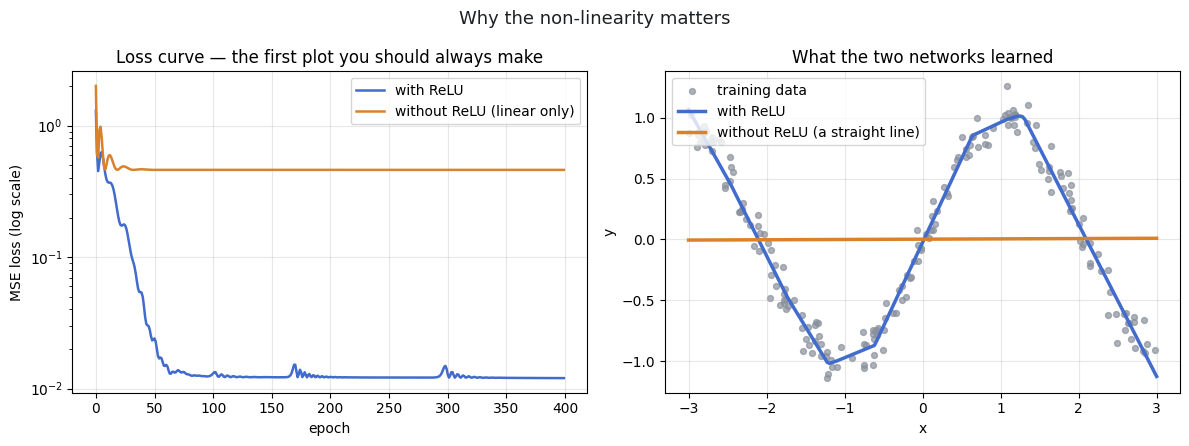

In [22]:
# Predictions on a fine grid, for the right-hand panel.
x_grid = torch.linspace(-3, 3, 200).reshape(-1, 1)      # (200, 1)
with torch.no_grad():                                   # evaluation: no gradients needed
    relu_fit = relu_net(x_grid)
    linear_fit = linear_net(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- left: loss curves -----------------------------------------------------
axes[0].plot(relu_losses, color=BAS_BLUE, lw=1.8, label="with ReLU")
axes[0].plot(linear_losses, color=BAS_AMBER, lw=1.8, label="without ReLU (linear only)")
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss (log scale)")
axes[0].set_title("Loss curve — the first plot you should always make")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- right: what the models learned ---------------------------------------
axes[1].scatter(x.numpy(), y.numpy(), s=18, color=BAS_GREY, alpha=0.7, label="training data")
axes[1].plot(x_grid.numpy(), relu_fit.numpy(), color=BAS_BLUE, lw=2.5, label="with ReLU")
axes[1].plot(x_grid.numpy(), linear_fit.numpy(), color=BAS_AMBER, lw=2.5,
             label="without ReLU (a straight line)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("What the two networks learned")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Why the non-linearity matters", fontsize=13, color=BAS_INK)
fig.tight_layout()
plt.show()

**Reading the chart.** On the left, the blue curve drops by two orders of magnitude and keeps improving; the amber curve flattens almost immediately at 0.4607 and never moves again — it has already found the best straight line, and a straight line is all it can ever be.

Look closely at that number: 0.4607 is **exactly the variance of `y`**. The linear model is doing no better than predicting the average of the training targets — on the right-hand panel it is the flat amber line at y ≈ 0, because for data this symmetric the best straight line is a horizontal one. It has learned literally nothing about the shape of the data. The blue model, same 49 parameters plus one `nn.ReLU()`, traces the curve out of straight segments — which is what ReLU networks do: they approximate curves by bending piecewise-linear pieces together.

This is the whole argument for "deep" learning in miniature. Capacity does not come from having many parameters; it comes from **alternating** linear transformations with non-linearities.

## 9. A complete PyTorch workflow, end to end

Time to do the real thing on a real dataset — and to compare honestly with scikit-learn. We use **iris** (the dataset from notebook 12): 150 flowers, 4 measurements each, 3 species. Bundled with scikit-learn, so nothing is downloaded.

The workflow is the notebook-12 workflow with two extra steps in the middle:

| Step | Notebook 12 (scikit-learn) | Here (PyTorch) |
|---|---|---|
| 1. Load | `load_iris()` | same |
| 2. Split | `train_test_split` | same |
| 3. Scale | `StandardScaler` | same — and now **mandatory** |
| 4. **Convert** | — | `torch.tensor(..., dtype=...)` |
| 5. Fit | `model.fit(X, y)` | **the training loop you just wrote** |
| 6. Evaluate | `model.score(X_test, y_test)` | forward pass inside `torch.no_grad()` |

### 9.1 Load, split, scale

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target          # NumPy arrays: (150, 4) and (150,)

print("features:", iris.feature_names)
print("classes :", iris.target_names)
print("X:", X.shape, " y:", y.shape)

# Split FIRST, so the test set stays untouched (notebook 12's cardinal rule)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\ntrain: {X_train.shape[0]} flowers | test: {X_test.shape[0]} flowers")

# Scale: fit the scaler on the TRAINING data only, then apply it to both
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nbefore scaling — mean:", X_train.mean(axis=0).round(2),
      "std:", X_train.std(axis=0).round(2))
print("after  scaling — mean:", X_train_scaled.mean(axis=0).round(2),
      "std:", X_train_scaled.std(axis=0).round(2))

features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
classes : ['setosa' 'versicolor' 'virginica']
X: (150, 4)  y: (150,)

train: 120 flowers | test: 30 flowers

before scaling — mean: [5.84 3.05 3.77 1.2 ] std: [0.84 0.45 1.76 0.76]
after  scaling — mean: [-0. -0.  0.  0.] std: [1. 1. 1. 1.]


(The `-0.` in the scaled means is just floating-point noise — the column means are zero to about 16 decimal places.)

> ⚠️ **Neural networks *need* scaled inputs.** Notebook 8 introduced `StandardScaler` as good practice; for gradient descent it is close to a requirement. The gradient of a weight is proportional to the size of its input, so a feature measured in thousands produces gradients thousands of times larger than a feature measured in units. One learning rate then cannot suit both: it is too large for one weight and too small for the other, and training either diverges or crawls. Standardising puts every feature on a comparable scale (mean 0, std 1) so a single learning rate works for all of them.
>
> Note that the scaler is fit on the training data only — fitting it on everything leaks test information into training, the mistake from notebook 12.

### 9.2 Convert to tensors

The one genuinely new step. Two dtype rules for classification:

- **features → `float32`** (the network's arithmetic dtype),
- **labels → `int64`** (`torch.long`), because `nn.CrossEntropyLoss` expects *class indices*, not one-hot vectors.

In [24]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("X_train_t:", tuple(X_train_t.shape), X_train_t.dtype)
print("y_train_t:", tuple(y_train_t.shape), y_train_t.dtype)
print("X_test_t :", tuple(X_test_t.shape), X_test_t.dtype)
print("\nfirst training flower:", X_train_t[0].numpy().round(2), "-> class", y_train_t[0].item())

X_train_t: (120, 4) torch.float32
y_train_t: (120,) torch.int64
X_test_t : (30, 4) torch.float32

first training flower: [-1.72 -0.33 -1.35 -1.32] -> class 0


### 9.3 Build the network

Four features in, three class scores out, with 16 hidden units in between — the architecture from the diagram in section 6. We reuse the `Net` class from section 7.

In [25]:
torch.manual_seed(42)
iris_net = Net(n_features=4, n_hidden=16, n_out=3)

print(iris_net)
n_params = sum(p.numel() for p in iris_net.parameters())
print(f"\ntrainable parameters: {n_params}  (16*4+16 + 3*16+3)")
print("training samples    :", X_train_t.shape[0])

Net(
  (hidden): Linear(in_features=4, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=3, bias=True)
)

trainable parameters: 131  (16*4+16 + 3*16+3)
training samples    : 120


131 parameters for 120 training samples — more knobs than data points. Keep that in mind when we look at the test score: this model has every opportunity to overfit.

### 9.4 Train

In [26]:
loss_fn = nn.CrossEntropyLoss()                        # classification loss
optimizer = optim.Adam(iris_net.parameters(), lr=0.05)

iris_losses = []
for epoch in range(200):
    logits = iris_net(X_train_t)             # 1. forward   -> (120, 3) raw scores
    loss = loss_fn(logits, y_train_t)        # 2. loss      -> one number

    optimizer.zero_grad()                    # 3. clear old gradients
    loss.backward()                          # 4. backward  -> fill .grad
    optimizer.step()                         # 5. update parameters

    iris_losses.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"epoch {epoch + 1:>3} | loss {loss.item():.4f}")

print(f"\nstarting loss {iris_losses[0]:.4f}  (an untrained 3-class model scores "
      f"about ln(3) = {np.log(3):.4f} — pure guessing)")

epoch  40 | loss 0.0415
epoch  80 | loss 0.0371
epoch 120 | loss 0.0328
epoch 160 | loss 0.0225
epoch 200 | loss 0.0143

starting loss 1.0461  (an untrained 3-class model scores about ln(3) = 1.0986 — pure guessing)


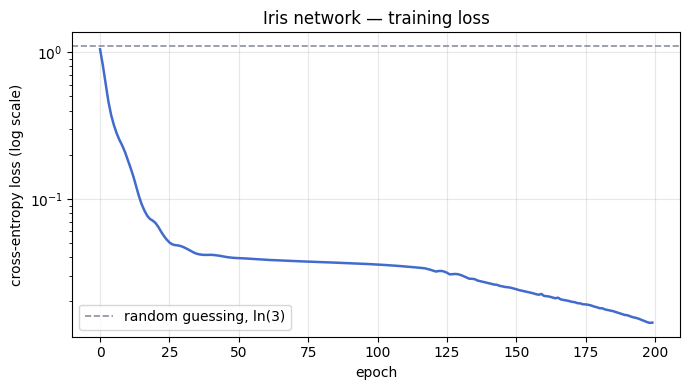

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iris_losses, color=BAS_BLUE, lw=1.8)
ax.axhline(np.log(3), color=BAS_GREY, ls="--", lw=1.2, label="random guessing, ln(3)")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss (log scale)")
ax.set_title("Iris network — training loss")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

A textbook loss curve: a steep drop in the first ~30 epochs, then a slow grind. Note what it does **not** tell you — this is *training* loss, so a beautiful curve is perfectly compatible with overfitting. Only the test set can tell you that.

### 9.5 Evaluate on the test set

In [28]:
iris_net.eval()                    # switch to evaluation mode (matters once you use dropout/batch-norm)

with torch.no_grad():              # no gradients needed -> faster, less memory
    test_logits = iris_net(X_test_t)
    test_pred = test_logits.argmax(dim=1)          # highest score wins
    test_acc = (test_pred == y_test_t).float().mean().item()

    train_pred = iris_net(X_train_t).argmax(dim=1)
    train_acc = (train_pred == y_train_t).float().mean().item()

print(f"train accuracy: {train_acc:.4f}")
print(f"test  accuracy: {test_acc:.4f}   ({int(test_acc * len(y_test))} of {len(y_test)} flowers correct)")

# Which flowers did it get wrong?
wrong = (test_pred != y_test_t).nonzero().flatten()
for i in wrong.tolist():
    print(f"  misclassified: true {iris.target_names[y_test[i]]:<10} "
          f"predicted {iris.target_names[test_pred[i].item()]}")

train accuracy: 1.0000
test  accuracy: 0.9333   (28 of 30 flowers correct)
  misclassified: true virginica  predicted versicolor
  misclassified: true versicolor predicted virginica


100 % on training data, 93.3 % on test data — the gap is the overfitting signature from notebook 11, exactly as the parameter count predicted. Both mistakes are versicolor ↔ virginica confusions, the two species that genuinely overlap (notebook 12's pair-plot showed why).

### 9.6 The honest comparison

Now the part that a hype-driven tutorial would skip. Same split, same scaled features, two scikit-learn models from notebook 12 — one line each.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
forest = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_scaled, y_train)

print(f"PyTorch network      : {test_acc:.4f}   ({n_params} parameters, hand-written training loop)")
print(f"Logistic regression  : {logreg.score(X_test_scaled, y_test):.4f}   (one line of code)")
print(f"Random forest        : {forest.score(X_test_scaled, y_test):.4f}   (one line of code)")

PyTorch network      : 0.9333   (131 parameters, hand-written training loop)
Logistic regression  : 0.9333   (one line of code)
Random forest        : 0.9000   (one line of code)


**The neural network exactly ties with logistic regression** — 28 of 30 flowers, the same two mistakes' worth of error — and logistic regression took one line instead of a training loop, trains instantly, and hands you interpretable coefficients. (The random forest does slightly worse here; with 30 test flowers, one flower is 3.3 percentage points, so treat these small differences as noise rather than a ranking.)

This is not a failure of PyTorch. It is the correct lesson, and worth remembering:

> **On small tabular datasets, the simple model is usually as good as the complicated one.** Deep learning wins when the data is big and structured — pixels, audio, text, graphs — where the network can discover features that no one hand-engineered. On 120 rows and 4 columns, there is nothing left for it to discover.

Knowing *which* tool a problem calls for is a more valuable skill than knowing how to run the fanciest one. You now have both tools, and one honest data point about the difference.

## 10. Where to go next

You have the core. Here is the map of what sits immediately around it.

**`Dataset` and `DataLoader` — learn this next.** We trained on the *entire* training set at once ("full-batch"), which works for 120 flowers and not for 120,000 images. Real training splits data into **mini-batches**:

```python
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

for epoch in range(n_epochs):
    for xb, yb in train_dl:              # the only change: an inner loop over batches
        loss = loss_fn(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

The five steps are untouched — they just run once per batch instead of once per epoch. Mini-batches also make training *better*, not merely feasible: the noise in each batch's gradient helps escape bad spots.

**GPUs.** `model.to(device)` and `xb.to(device)`, with the `device` line from section 2. Nothing else changes. Worth it once your model is big enough that the transfer cost is negligible — a threshold these toy models are far below.

**Architectures.** Convolutional networks (images), recurrent networks and **transformers** (sequences, language) differ from what you built only in *which layers* go into `forward`. The training loop is byte-for-byte the same five steps. That is why this notebook spent so long on those five lines: they do not change.

**Also worth learning, roughly in this order:** overfitting controls (`nn.Dropout`, weight decay, early stopping), learning-rate schedulers, `nn.BCEWithLogitsLoss` for binary problems, saving and loading with `state_dict`, and Hugging Face `transformers` for pretrained models.

**Go deeper with the summer school.** The Bridging AI & Society [**Hands-On-Notebooks**](https://github.com/BridgingAISocietySummerSchools/Hands-On-Notebooks) repository contains the fuller machine-learning and deep-learning material from the summer schools — more architectures, more datasets, and the societal-impact discussions that go with them. It is the natural next repository after this course.

## 11. 💬 A reflection: this is the loop

Take one more look at what you wrote in section 8:

```python
predictions = model(X_train)
loss = loss_fn(predictions, y_train)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

**That is, in essence, the loop that trains the large models you read about in the news.** Not an analogy or a simplified teaching version — the same five steps. A large language model swaps your 49 parameters for hundreds of billions, your 200 data points for a substantial fraction of the written internet, your CPU-second for months on thousands of GPUs, and `nn.Linear` for stacked transformer blocks. The mechanism does not change: predict, measure the error, compute gradients, step downhill.

Two consequences worth sitting with:

- **Demystification.** There is no reasoning module hidden in there, no comprehension step. The system adjusts numbers to reduce a prediction error on data it was shown. Everything a model appears to *know* came from that data, via that loop.
- **Responsibility.** The loop minimises the loss it was given on the data it was given — faithfully, and without judgement. If the data encodes historical bias, the loop reproduces it efficiently; the errors that the loss function does not measure are errors the model will happily keep making. Choosing the data and choosing the loss are therefore not technical details. They are where the values go in.

**Questions to sit with:** Whose data trained the systems you use? What error is their loss function *not* measuring? And who decided that the thing being minimised was the right thing to minimise?

## 🧪 Practice exercises

Five exercises, roughly in the order the notebook introduced things. Try each before revealing the solution — especially the debugging one.

### Exercise 13.1 — Tensor gymnastics

1. Create a tensor `a` containing the numbers 0 to 11 as **floats**, shaped `(3, 4)`. Print it, its `shape` and its `dtype`.
2. Reshape it to `(4, 3)` and print the new shape.
3. Compute `a @ a.T` and print the result's shape. Explain in a comment why that shape is what it is.
4. Compute the sum over `dim=0` and the mean over `dim=1`. Say in a comment which one gives a value per column and which per row.
5. Select the last column of `a` using slicing.

In [30]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
a = torch.arange(12.0).reshape(3, 4)      # the ".0" makes it float32
print(a)
print("shape:", tuple(a.shape), "dtype:", a.dtype)

print("reshaped:", tuple(a.reshape(4, 3).shape))

# (3,4) @ (4,3) -> (3,3): the inner dimension 4 cancels, the outer ones survive
print("a @ a.T shape:", tuple((a @ a.T).shape))

print("a.sum(dim=0):", a.sum(dim=0))      # dim 0 (rows) collapses -> one value PER COLUMN
print("a.mean(dim=1):", a.mean(dim=1))    # dim 1 (columns) collapses -> one value PER ROW

print("last column:", a[:, -1])
```

Output:

```
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
shape: (3, 4) dtype: torch.float32
reshaped: (4, 3)
a @ a.T shape: (3, 3)
a.sum(dim=0): tensor([12., 15., 18., 21.])
a.mean(dim=1): tensor([1.5000, 5.5000, 9.5000])
last column: tensor([ 3.,  7., 11.])
```

**Reasoning.** `torch.arange(12)` would give an `int64` tensor that cannot carry gradients — `12.0` makes it `float32`. The rule for `@` is `(n, k) @ (k, m) -> (n, m)`: here `(3, 4) @ (4, 3) -> (3, 3)`. And the reduction rule is the NumPy `axis=` rule with a new name: **the dimension you name is the one that disappears.**

</details>

### Exercise 13.2 — Check autograd's homework

For $y = x^3 + 2x$, the derivative is $\frac{dy}{dx} = 3x^2 + 2$.

1. Work out by hand what the gradient must be at $x = 2$ and at $x = -1$.
2. Use PyTorch (`requires_grad=True`, `.backward()`, `.grad`) to compute both, and check they match your hand calculation.
3. **Important:** use a *fresh* tensor for the second value — or explain in a comment what happens if you reuse the first one without resetting `.grad`.

In [31]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
# By hand: dy/dx = 3x^2 + 2
#   at x =  2:  3*4 + 2 = 14
#   at x = -1:  3*1 + 2 = 5

for value, expected in [(2.0, 14.0), (-1.0, 5.0)]:
    xi = torch.tensor(value, requires_grad=True)   # a FRESH tensor each time
    yi = xi ** 3 + 2 * xi
    yi.backward()
    print(f"x = {value:>4}:  autograd {xi.grad.item():.1f}  |  by hand {expected:.1f}"
          f"  |  match: {xi.grad.item() == expected}")

# Reusing one tensor without resetting would ADD the two gradients (14 + 5 = 19),
# because .backward() accumulates into .grad. xi.grad.zero_() prevents that.
```

Output:

```
x =  2.0:  autograd 14.0  |  by hand 14.0  |  match: True
x = -1.0:  autograd 5.0  |  by hand 5.0  |  match: True
```

**Reasoning.** Autograd is not an approximation — it applies the chain rule exactly, so the numbers agree with your calculus to the last digit. The accumulation trap in point 3 is the same one that makes `optimizer.zero_grad()` necessary; meeting it on a two-line example is much cheaper than meeting it inside a training run.

</details>

### Exercise 13.3 — Your own `nn.Module`

Write a class `DeeperNet(nn.Module)` for iris-shaped data with **two** hidden layers: `4 → 16 → 8 → 3`, with a ReLU after each hidden layer.

1. Implement `__init__` (three `nn.Linear` layers) and `forward`.
2. Instantiate it, print the model, and print the total number of trainable parameters.
3. Verify by hand that the parameter count is what you expect, and check that a batch of 5 samples comes out with shape `(5, 3)`.

In [32]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
class DeeperNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)          # no activation on the output: CrossEntropyLoss wants logits


torch.manual_seed(0)
deeper = DeeperNet()
print(deeper)

total = sum(p.numel() for p in deeper.parameters())
by_hand = (16 * 4 + 16) + (8 * 16 + 8) + (3 * 8 + 3)
print("\nparameters:", total, "| by hand:", by_hand)

out = deeper(torch.randn(5, 4))
print("output shape:", tuple(out.shape))
```

Output:

```
DeeperNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=3, bias=True)
)

parameters: 243 | by hand: 243
output shape: (5, 3)
```

**Reasoning.** Each `nn.Linear(n_in, n_out)` holds `n_out * n_in` weights plus `n_out` biases, so the count is `80 + 136 + 27 = 243`. Note that this deeper network has *nearly twice* the parameters of the 131-parameter model from section 9 — on 120 training flowers, that is more capacity, more overfitting risk, and almost certainly no better test accuracy. Bigger is not automatically better.

</details>

### Exercise 13.4 — Debug me 🐞

The cell below trains the same ReLU network on the same curved data as section 8. It runs without any error — but the loss **does not move at all**: it is identical at epoch 1 and epoch 200, to six decimal places.

Run it, look at the printed losses, and work out why. Then fix it.

*Hint: all five steps of the loop are present. Read them in the order they execute.*

In [33]:
# The same curved dataset as section 8, rebuilt so this cell stands on its own.
torch.manual_seed(0)
x_curve = torch.rand(200, 1) * 6 - 3
y_curve = torch.sin(1.5 * x_curve) + 0.1 * torch.randn(200, 1)

# 🐞 This runs, but the model never learns. Why?
torch.manual_seed(42)
buggy_net = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

loss_fn_buggy = nn.MSELoss()
optimizer_buggy = optim.Adam(buggy_net.parameters(), lr=0.05)

buggy_losses = []
for epoch in range(200):
    predictions = buggy_net(x_curve)
    loss = loss_fn_buggy(predictions, y_curve)

    loss.backward()
    optimizer_buggy.zero_grad()
    optimizer_buggy.step()

    buggy_losses.append(loss.item())

print(f"epoch   1 | loss {buggy_losses[0]:.6f}")
print(f"epoch 100 | loss {buggy_losses[99]:.6f}")
print(f"epoch 200 | loss {buggy_losses[-1]:.6f}")
print("\nloss changed at all?", buggy_losses[0] != buggy_losses[-1])

epoch   1 | loss 1.297206
epoch 100 | loss 1.297206
epoch 200 | loss 1.297206

loss changed at all? False


<details>
<summary>💡 Click to reveal the solution</summary>

**The bug:** `optimizer.zero_grad()` is called **after** `loss.backward()` instead of before it. So every epoch does this:

1. `loss.backward()` computes the gradients and stores them in `.grad` ✅
2. `optimizer.zero_grad()` immediately **erases** them 🐞
3. `optimizer.step()` updates the parameters using gradients that are all zero → nothing moves

The gradients are computed correctly and then thrown away, so the parameters never change and the loss is frozen at its starting value. No error, no warning — the run just quietly does nothing.

**The fix** — put the reset before the backward pass:

```python
torch.manual_seed(42)
fixed_net = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))

loss_fn_fixed = nn.MSELoss()
optimizer_fixed = optim.Adam(fixed_net.parameters(), lr=0.05)

fixed_losses = []
for epoch in range(200):
    loss = loss_fn_fixed(fixed_net(x_curve), y_curve)

    optimizer_fixed.zero_grad()   # 3. clear  <-- BEFORE backward
    loss.backward()               # 4. compute gradients
    optimizer_fixed.step()        # 5. update

    fixed_losses.append(loss.item())

print(f"epoch   1 | loss {fixed_losses[0]:.6f}")
print(f"epoch 200 | loss {fixed_losses[-1]:.6f}")
```

Output:

```
epoch   1 | loss 1.297206
epoch 200 | loss 0.012207
```

**Reasoning.** The order `zero_grad → backward → step` is not stylistic: gradients accumulate into `.grad`, so the reset must happen *before* the gradients you intend to use are computed. The two classic variants of this bug are worth recognising on sight:

| Mistake | Symptom |
|---|---|
| `zero_grad()` **after** `backward()` | loss completely flat — the model never learns |
| `zero_grad()` **missing entirely** | loss wanders or explodes — every step uses the sum of all past gradients |

Both run without raising anything, which is exactly what makes them dangerous. When a training run behaves oddly, check the order of those three lines first. And note the diagnostic that caught it: **plotting or printing the loss over time.** A model that silently does nothing looks identical to a working one until you look at the curve.

</details>

### Exercise 13.5 — A full workflow of your own

Repeat section 9 on the **breast cancer** dataset (`from sklearn.datasets import load_breast_cancer`): 569 patients, 30 features from digitised tumour images, 2 classes (malignant / benign).

1. Load it, split 80/20 with `stratify=y` and `random_state=42`, and standardise the features (fit the scaler on train only).
2. Convert to tensors — features `float32`, labels `torch.long`.
3. Build a network `30 → 16 → 2` (you can reuse `Net` from section 7) and train it for 300 epochs with `nn.CrossEntropyLoss` and `Adam(lr=0.01)`.
4. Evaluate the test accuracy inside `torch.no_grad()`.
5. Compare against a `RandomForestClassifier(n_estimators=200, random_state=42)` and write one sentence about what you conclude.

In [34]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
from sklearn.datasets import load_breast_cancer

# 1. load, split, scale
cancer = load_breast_cancer()
Xc, yc = cancer.data, cancer.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, stratify=yc, random_state=42
)
sc = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = sc.transform(Xc_train), sc.transform(Xc_test)
print("train:", Xc_train_s.shape, " test:", Xc_test_s.shape)

# 2. to tensors
Xc_train_t = torch.tensor(Xc_train_s, dtype=torch.float32)
Xc_test_t = torch.tensor(Xc_test_s, dtype=torch.float32)
yc_train_t = torch.tensor(yc_train, dtype=torch.long)
yc_test_t = torch.tensor(yc_test, dtype=torch.long)

# 3. build and train
torch.manual_seed(0)
cancer_net = Net(n_features=30, n_hidden=16, n_out=2)
loss_fn_c = nn.CrossEntropyLoss()
opt_c = optim.Adam(cancer_net.parameters(), lr=0.01)

for epoch in range(300):
    loss = loss_fn_c(cancer_net(Xc_train_t), yc_train_t)
    opt_c.zero_grad()
    loss.backward()
    opt_c.step()
print(f"final training loss: {loss.item():.4f}")

# 4. evaluate
cancer_net.eval()
with torch.no_grad():
    acc_nn = (cancer_net(Xc_test_t).argmax(dim=1) == yc_test_t).float().mean().item()

# 5. baseline
forest_c = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xc_train_s, yc_train)
acc_rf = forest_c.score(Xc_test_s, yc_test)

print(f"PyTorch network: {acc_nn:.4f}")
print(f"Random forest  : {acc_rf:.4f}")
```

Output:

```
train: (455, 30)  test: (114, 30)
final training loss: 0.0034
PyTorch network: 0.9561
Random forest  : 0.9561
```

**Reasoning.** A dead heat — 109 of 114 patients correct for both models. The training loss of 0.0034 means the network has essentially memorised the training set, and the extra capacity bought nothing on the test set. Same conclusion as section 9, on a bigger and more realistic dataset: **for tabular data of this size, a tree ensemble is the sensible default**, and it comes with feature importances (notebook 12) instead of 530 uninterpretable weights.

One more thing worth naming: this is medical data, and "95.6 % accurate" hides the question that matters — *which* five patients were misclassified, and in which direction? A false "benign" is not the same kind of error as a false "malignant". Accuracy alone is the wrong metric for a decision like this one; the confusion matrix and recall from notebook 12 are the right tools.

</details>

## 🧠 Key takeaways

1. **A tensor is a NumPy array with two superpowers**: it can carry gradients (`requires_grad`) and move to a GPU (`.to(device)`). Everything you learned in notebook 6 transfers — `dim=` is the new spelling of `axis=`.
2. **Autograd is bookkeeping for the chain rule**, not magic. `.backward()` on a scalar fills in `.grad` for every input, and you can check it against your own calculus — `y = x²` at `x = 3` really does give 6.
3. **A neural network is stacked linear layers plus non-linearities.** Without the non-linearity the whole stack collapses into a single matrix multiplication and can only draw straight lines — we verified this both algebraically and with a loss curve stuck at 0.46.
4. **The training loop is five steps** — forward, loss, `zero_grad`, `backward`, `step` — and they never change, no matter how large the model.
5. **`optimizer.zero_grad()` must come before `loss.backward()`.** Gradients accumulate; misplacing or forgetting the reset produces a model that silently fails to learn. Always plot the loss curve.
6. **Two ways to define a model**: `nn.Sequential` for a straight pipeline, `class Net(nn.Module)` with `__init__`/`forward` for everything else. The class version is what real code uses.
7. **Neural networks need standardised inputs.** Unscaled features make one learning rate wrong for every weight. Fit the scaler on training data only.
8. **Evaluate inside `torch.no_grad()`** and, for real models, call `model.eval()` first.
9. **Be honest about tool choice.** On iris, a 131-parameter network tied exactly with a one-line logistic regression; on breast cancer it tied with a random forest. Deep learning earns its complexity on large, structured data — not on small tables.
10. **The loop you wrote is the loop that trains frontier models.** Scale and data differ; the mechanism does not. Which is also why the choice of data and loss function is an ethical choice, not just a technical one.

## ✅ Self-assessment

- [ ] Create tensors with `torch.tensor`, `zeros`, `ones`, `arange`, `randn`, and inspect `shape` and `dtype`.
- [ ] Explain why PyTorch defaults to `float32` while NumPy defaults to `float64`.
- [ ] Convert between NumPy arrays and tensors, and say when the memory is shared.
- [ ] Predict the output shape of `(4, 6) @ (6, 2)`, and of `A.sum(dim=0)` for a `(4, 6)` tensor.
- [ ] Compute a gradient with autograd and verify it by hand.
- [ ] Explain in one sentence why a network without activation functions is only a linear model.
- [ ] Write the five-step training loop from memory, in the right order.
- [ ] Explain why `optimizer.zero_grad()` exists and what happens if it is misplaced or missing.
- [ ] Define the same small network twice: once with `nn.Sequential`, once as an `nn.Module` subclass, and count its parameters.
- [ ] Run a full workflow — split, scale, to tensors, train, evaluate under `torch.no_grad()` — and compare it against a scikit-learn baseline.
- [ ] Say when you would choose PyTorch over scikit-learn, and when you would not.

## 🚀 Next step

You now have the whole toolkit: Python, NumPy, pandas, cleaning, visualisation, EDA, machine learning, scikit-learn and PyTorch. Time to put it all together.

Continue with **Notebook 14 — Capstone Project** ([`14_capstone_project.ipynb`](14_capstone_project.ipynb)), where you run a complete data-science project end to end on your own.

*(Previous: **Notebook 12 — The Scikit-Learn Workflow** ([`12_scikit_learn_workflow.ipynb`](12_scikit_learn_workflow.ipynb)).)*

---

*Part of the [Bridging AI & Society Summer Schools](https://bridgingaiandsociety.org) course materials. For more machine-learning and deep-learning notebooks, see the [Hands-On-Notebooks](https://github.com/BridgingAISocietySummerSchools/Hands-On-Notebooks) repository.*